# Start

In [25]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("kushagrapandya/visdrone-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'visdrone-dataset' dataset.
Path to dataset files: /kaggle/input/visdrone-dataset


In [26]:
# View Dataset
import os

for root, dirs, files in os.walk("/kaggle/input/visdrone-dataset"):
    level = root.replace("/kaggle/input/visdrone-dataset", "").count(os.sep)
    indent = " " * 2 * level
    print(f"{indent}{os.path.basename(root)}/")
    if level < 2:
        subindent = " " * 2 * (level + 1)
        for file in files[:3]:
            print(f"{subindent}{file}")

visdrone-dataset/
  VisDrone.yaml
  VisDrone2019-DET-test-challenge/
    VisDrone2019-DET-test-challenge/
      images/
  VisDrone2019-DET-test-dev/
    VisDrone2019-DET-test-dev/
      annotations/
      images/
  VisDrone2019-DET-train/
    VisDrone2019-DET-train/
      annotations/
      images/
  VisDrone2019-DET-val/
    VisDrone2019-DET-val/
      annotations/
      images/


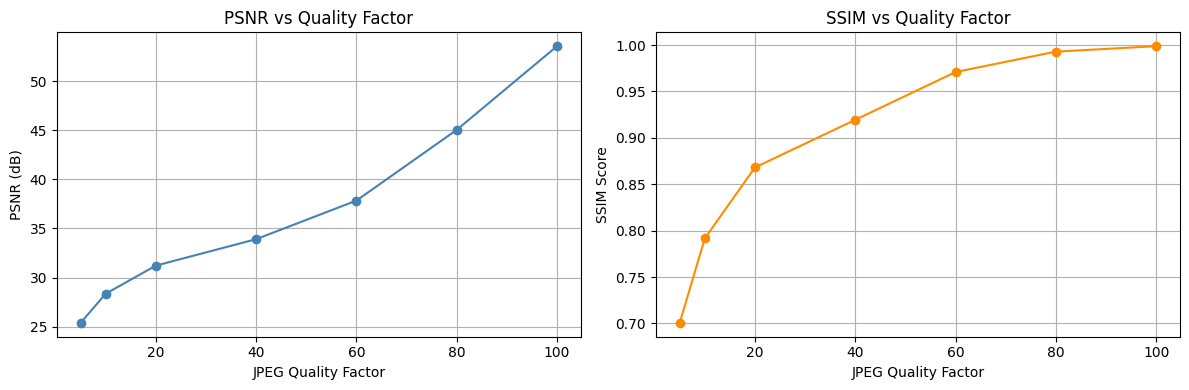


Summary Table:
QF     PSNR (dB)    SSIM    
--------------------------
5      25.38        0.7007  
10     28.35        0.7917  
20     31.21        0.8681  
40     33.91        0.9195  
60     37.84        0.9709  
80     45.05        0.9929  
100    53.58        0.9988  


In [27]:
import os
import random
import cv2
import numpy as np
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim
import matplotlib.pyplot as plt

# Path to training images
image_dir = "/kaggle/input/visdrone-dataset/VisDrone2019-DET-train/VisDrone2019-DET-train/images/"

# Get 50 random images
all_images = [f for f in os.listdir(image_dir) if f.endswith(".jpg")]
sample_images = random.sample(all_images, 50)

# Quality factors to test
quality_factors = [5, 10, 20, 40, 60, 80, 100]

# Store results
results = {qf: {"psnr": [], "ssim": []} for qf in quality_factors}

for img_name in sample_images:
    img_path = os.path.join(image_dir, img_name)
    original = cv2.imread(img_path)

    for qf in quality_factors:
        # Compress to JPEG in memory and decode back
        encode_param = [int(cv2.IMWRITE_JPEG_QUALITY), qf]
        _, encoded = cv2.imencode(".jpg", original, encode_param)
        compressed = cv2.imdecode(encoded, cv2.IMREAD_COLOR)

        # Compute metrics
        p = psnr(original, compressed)
        s = ssim(original, compressed, channel_axis=2)

        results[qf]["psnr"].append(p)
        results[qf]["ssim"].append(s)

# Average across all images
avg_psnr = [np.mean(results[qf]["psnr"]) for qf in quality_factors]
avg_ssim = [np.mean(results[qf]["ssim"]) for qf in quality_factors]

# Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(quality_factors, avg_psnr, marker="o", color="steelblue")
ax1.set_title("PSNR vs Quality Factor")
ax1.set_xlabel("JPEG Quality Factor")
ax1.set_ylabel("PSNR (dB)")
ax1.grid(True)

ax2.plot(quality_factors, avg_ssim, marker="o", color="darkorange")
ax2.set_title("SSIM vs Quality Factor")
ax2.set_xlabel("JPEG Quality Factor")
ax2.set_ylabel("SSIM Score")
ax2.grid(True)

plt.tight_layout()
plt.savefig("compression_audit.png", dpi=150)
plt.show()

print("\nSummary Table:")
print(f"{'QF':<6} {'PSNR (dB)':<12} {'SSIM':<8}")
print("-" * 26)
for i, qf in enumerate(quality_factors):
    print(f"{qf:<6} {avg_psnr[i]:<12.2f} {avg_ssim[i]:<8.4f}")

In [28]:
!pip install ultralytics -q

In [29]:
#Loading Yolo Nano Model
from ultralytics import YOLO

model = YOLO("yolov8n.pt")
print("Model loaded successfully")

Model loaded successfully


In [30]:
# The VisDrone annotation format is: x, y, width, height, score, category, truncation, occlusion

ann_dir = "/kaggle/input/visdrone-dataset/VisDrone2019-DET-val/VisDrone2019-DET-val/annotations/"
ann_files = os.listdir(ann_dir)

with open(os.path.join(ann_dir, ann_files[0]), "r") as f:
    print(f.read()[:500])

868,141,54,26,0,0,0,0
634,0,34,44,0,0,0,0
666,4,44,47,0,0,0,0
589,27,25,25,0,0,0,0
722,32,51,34,0,0,0,0
331,545,169,113,1,4,0,0
200,378,82,59,1,4,0,0
267,311,70,61,1,4,0,0
695,548,85,116,1,4,0,0
814,480,70,80,1,4,0,0
707,303,46,44,1,4,0,0
257,187,14,15,1,10,0,1
366,175,10,25,1,1,0,0
374,176,9,25,1,1,0,1
386,220,12,29,1,1,0,0
419,203,10,22,1,1,0,0
397,244,11,27,1,1,0,0
424,240,9,27,1,1,0,1
421,236,9,29,1,1,0,2
456,162,31,29,1,4,0,1
477,143,28,24,1,4,0,1
493,136,21,22,1,4,0,1
491,121,23,23,1,4,0,1


In [31]:
val_img_dir = "/kaggle/input/visdrone-dataset/VisDrone2019-DET-val/VisDrone2019-DET-val/images/"
val_ann_dir = "/kaggle/input/visdrone-dataset/VisDrone2019-DET-val/VisDrone2019-DET-val/annotations/"

# Output directory for converted labels
output_label_dir = "/content/visdrone_yolo_labels/"
os.makedirs(output_label_dir, exist_ok=True)

converted = 0
skipped = 0

for ann_file in os.listdir(val_ann_dir):
    img_name = ann_file.replace(".txt", ".jpg")
    img_path = os.path.join(val_img_dir, img_name)

    img = cv2.imread(img_path)
    if img is None:
        skipped += 1
        continue

    h, w = img.shape[:2]
    yolo_lines = []

    with open(os.path.join(val_ann_dir, ann_file), "r") as f:
        for line in f.readlines():
            parts = line.strip().split(",")
            if len(parts) < 6:
                continue

            x, y, bw, bh, score, category = int(parts[0]), int(parts[1]), int(parts[2]), int(parts[3]), int(parts[4]), int(parts[5])

            # Skip ignored regions
            if score == 0:
                continue

            # Skip category 0 (ignored) and category 11 (others)
            if category == 0 or category == 11:
                continue

            # Convert to YOLO normalized xywh
            x_center = (x + bw / 2) / w
            y_center = (y + bh / 2) / h
            norm_w = bw / w
            norm_h = bh / h

            # YOLO categories are 0-indexed, VisDrone starts at 1
            yolo_class = category - 1

            yolo_lines.append(f"{yolo_class} {x_center:.6f} {y_center:.6f} {norm_w:.6f} {norm_h:.6f}")

    out_path = os.path.join(output_label_dir, ann_file)
    with open(out_path, "w") as f:
        f.write("\n".join(yolo_lines))

    converted += 1

print(f"Converted: {converted} annotation files")
print(f"Skipped: {skipped} files")

Converted: 548 annotation files
Skipped: 0 files


In [32]:
import os
import cv2

train_img_dir = "/kaggle/input/visdrone-dataset/VisDrone2019-DET-train/VisDrone2019-DET-train/images/"
train_ann_dir = "/kaggle/input/visdrone-dataset/VisDrone2019-DET-train/VisDrone2019-DET-train/annotations/"

output_train_label_dir = "/content/visdrone_yolo_train_labels/"
os.makedirs(output_train_label_dir, exist_ok=True)

converted = 0
skipped = 0

for ann_file in os.listdir(train_ann_dir):
    img_name = ann_file.replace(".txt", ".jpg")
    img_path = os.path.join(train_img_dir, img_name)

    img = cv2.imread(img_path)
    if img is None:
        skipped += 1
        continue

    h, w = img.shape[:2]
    yolo_lines = []

    with open(os.path.join(train_ann_dir, ann_file), "r") as f:
        for line in f.readlines():
            parts = line.strip().split(",")
            if len(parts) < 6:
                continue

            x, y, bw, bh, score, category = int(parts[0]), int(parts[1]), int(parts[2]), int(parts[3]), int(parts[4]), int(parts[5])

            if score == 0:
                continue
            if category == 0 or category == 11:
                continue

            x_center = (x + bw / 2) / w
            y_center = (y + bh / 2) / h
            norm_w = bw / w
            norm_h = bh / h

            yolo_class = category - 1
            yolo_lines.append(f"{yolo_class} {x_center:.6f} {y_center:.6f} {norm_w:.6f} {norm_h:.6f}")

    out_path = os.path.join(output_train_label_dir, ann_file)
    with open(out_path, "w") as f:
        f.write("\n".join(yolo_lines))

    converted += 1

print(f"Converted: {converted} annotation files")
print(f"Skipped: {skipped} files")

Converted: 6471 annotation files
Skipped: 0 files


In [33]:
# Check what's actually in the val labels directory
val_labels = "/content/visdrone/val/labels/"
print("Val labels directory contents:")
for item in os.listdir(val_labels):
    print(f"  {item}")
    subpath = os.path.join(val_labels, item)
    if os.path.isdir(subpath) or os.path.islink(subpath):
        sub_items = os.listdir(subpath)
        print(f"    contains {len(sub_items)} items")
        print(f"    sample: {sub_items[:3]}")

Val labels directory contents:
  0000330_00001_d_0000800.txt
  0000356_04313_d_0000651.txt
  0000215_00447_d_0000257.txt
  0000154_00001_d_0000001.txt
  0000271_03801_d_0000391.txt
  0000154_01201_d_0000001.txt
  0000364_01177_d_0000799.txt
  0000291_01401_d_0000875.txt
  0000116_00819_d_0000084.txt
  0000356_03333_d_0000646.txt
  0000276_03801_d_0000526.txt
  0000312_00001_d_0000414.txt
  0000023_00000_d_0000008.txt
  0000291_02201_d_0000879.txt
  0000289_01201_d_0000817.txt
  0000348_00589_d_0000409.txt
  0000166_00558_d_0000118.txt
  0000327_03201_d_0000727.txt
  0000215_03226_d_0000264.txt
  0000333_02941_d_0000016.txt
  0000295_02000_d_0000031.txt
  0000196_04512_d_0000144.txt
  0000327_03801_d_0000730.txt
  0000356_03725_d_0000648.txt
  0000283_00401_d_0000676.txt
  0000193_02606_d_0000117.txt
  0000271_04801_d_0000396.txt
  0000271_05201_d_0000398.txt
  0000289_05401_d_0000838.txt
  0000301_00001_d_0000156.txt
  0000291_04201_d_0000889.txt
  0000291_04401_d_0000890.txt
  0000295

In [34]:
import os
import shutil

# Remove old broken structure
shutil.rmtree("/content/visdrone", ignore_errors=True)

# Recreate clean structure
os.makedirs("/content/visdrone/train", exist_ok=True)
os.makedirs("/content/visdrone/val", exist_ok=True)

# Symlink images and labels at the correct level
os.symlink(
    "/kaggle/input/visdrone-dataset/VisDrone2019-DET-train/VisDrone2019-DET-train/images",
    "/content/visdrone/train/images"
)
os.symlink(
    "/content/visdrone_yolo_train_labels",
    "/content/visdrone/train/labels"
)
os.symlink(
    "/kaggle/input/visdrone-dataset/VisDrone2019-DET-val/VisDrone2019-DET-val/images",
    "/content/visdrone/val/images"
)
os.symlink(
    "/content/visdrone_yolo_labels",
    "/content/visdrone/val/labels"
)

# Verify
for split in ["train", "val"]:
    imgs = len(os.listdir(f"/content/visdrone/{split}/images"))
    lbls = len(os.listdir(f"/content/visdrone/{split}/labels"))
    print(f"{split} — images: {imgs}, labels: {lbls}")

train — images: 6471, labels: 6471
val — images: 548, labels: 548


In [35]:
import yaml

visdrone_classes = [
    "pedestrian", "people", "bicycle", "car", "van",
    "truck", "tricycle", "awning-tricycle", "bus", "motor"
]

yaml_content = {
    "path": "/content/visdrone",
    "train": "train/images",
    "val": "val/images",
    "nc": 10,
    "names": visdrone_classes
}

with open("/content/visdrone_v2.yaml", "w") as f:
    yaml.dump(yaml_content, f)

print("YAML updated successfully")

YAML updated successfully


In [36]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

results = model.train(
    data="/content/visdrone_v2.yaml",
    epochs=20,
    imgsz=640,
    batch=16,
    name="visdrone_baseline_v2",
    project="/content/runs",
    verbose=True
)

print("Training complete")

Ultralytics 8.4.41 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/visdrone_v2.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=visdrone_baseline_v2-2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, 

/usr/local/lib/python3.12/dist-packages/ultralytics/utils/metrics.py:839: RuntimeWarning: Mean of empty slice.
  i = smooth(f1_curve.mean(0), 0.1).argmax()  # max F1 index
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:130: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(



      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
       2/20      2.43G          0      72.52          0          0        640: 7% ╸─────────── 29/405 3.3it/s 8.6s<1:56


KeyboardInterrupt: 